# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

NETID = 'ym31'   # <-- set this
d = np.genfromtxt(f'../../labs/05/data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

31 epochs over 855 days; median quoted error 1.67 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


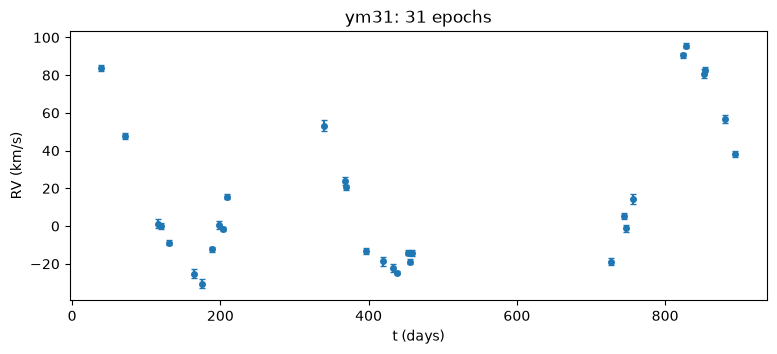

highest periodogram peaks:
  P =  270.31 d   power = 0.988
  P =   14.57 d   power = 0.437
  P =  152.56 d   power = 0.414
  P =   29.20 d   power = 0.412
  P =    4.79 d   power = 0.410
  P =    5.81 d   power = 0.386


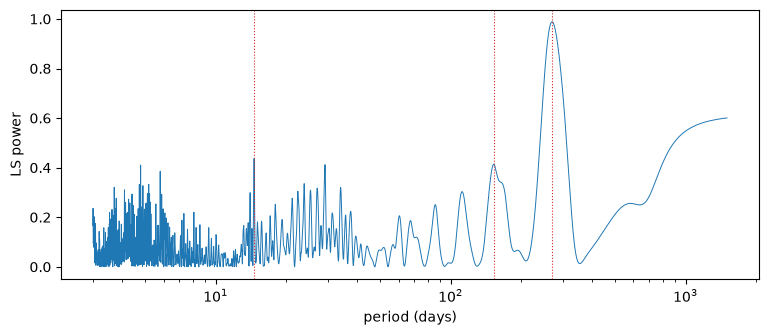

In [2]:
# Part 1: look at the data first
plt.figure(figsize=(9, 3.5))
plt.errorbar(t, rv, sig, fmt='o', ms=4, capsize=2)
plt.xlabel('t (days)')
plt.ylabel('RV (km/s)')
plt.title(f'{NETID}: {t.size} epochs')
plt.show()

freq = np.linspace(1/1500., 1/3., 120000)
ls = LombScargle(t, rv, sig)
power = ls.power(freq)
periods = 1. / freq
pk, _ = find_peaks(power)
top = pk[np.argsort(power[pk])[::-1][:6]]
print('highest periodogram peaks:')
for i in top:
    print(f'  P = {periods[i]:7.2f} d   power = {power[i]:.3f}')
P_ls = periods[top[0]]


plt.figure(figsize=(9, 3.5))
plt.plot(periods, power, lw=0.7)
for i in top[:3]:
    plt.axvline(periods[i], color='C3', ls=':', lw=0.8)
plt.xscale('log')
plt.xlabel('period (days)')
plt.ylabel('LS power')
plt.show()

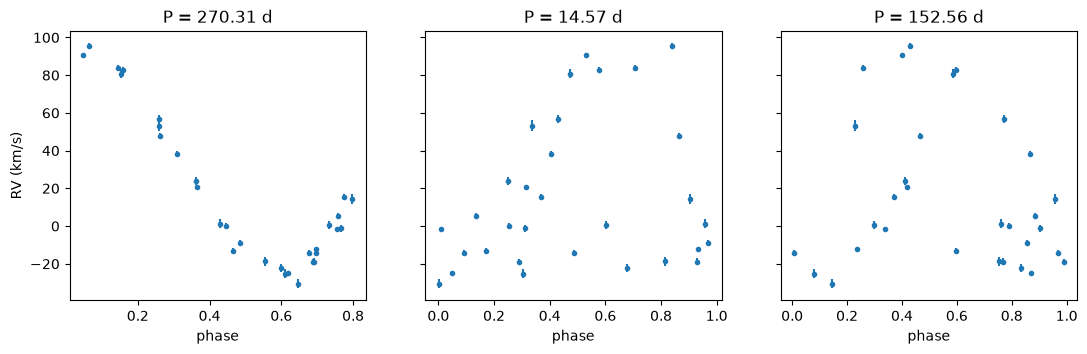

In [3]:
# phase fold at the best few candidates
cands = [periods[i] for i in top[:3]]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for a, P in zip(ax, cands):
    ph = (t / P) % 1.0
    a.errorbar(ph, rv, sig, fmt='o', ms=3)
    a.set_title(f'P = {P:.2f} d')
    a.set_xlabel('phase')
ax[0].set_ylabel('RV (km/s)')
plt.show()

**ANSWER (a few sentences):**

From the periodogram there's really only one plausible period, the peak near 270 d has power 0.99 and the next ones (14.6, 152.6, 29.2 d) are all around 0.4. Folding at 270 d gives a smooth curve and the other two folds look like noise. But Lomb-Scargle is fitting a sine wave at each period and an eccentric orbit isn't a sine wave, so some of the power goes into harmonics and the peak doesn't have to be exactly at the true period. That's why you still need to do actual Keplerian fits to decide (Part 2).

The other peaks come from the gaps between the three seasons, which are about a year apart. That makes aliases at $1/P \pm 1/(\text{1 yr})$, and the 152 d peak is roughly where $1/270 + 1/365$ ends up. The short period peaks are from the uneven spacing of the nights within each season.

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___, $\gamma = $ ___ $\pm$ ___ km/s, jitter $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$. Is your companion a black-hole candidate? One sentence.


In [4]:
# Part 2: likelihood, prior, posterior
# parameters x = [P, K, sqrt(e)cos(w), sqrt(e)sin(w), Tp, gamma, ln s]
names = ['P', 'K', 'e', 'omega', 'Tp', 'gamma', 's']

def lnlike(x, v):
    P, K, h, k, Tp, gamma, lns = x
    model = kepler_rv(t, P, K, h**2 + k**2, np.arctan2(k, h), Tp, gamma)
    var = sig**2 + np.exp(lns)**2
    return -0.5 * np.sum((v - model)**2 / var + np.log(2 * np.pi * var))

def lnprior(x, Tp_mid):
    P, K, h, k, Tp, gamma, lns = x
    if not (2. < P < 1000. and 0. < K < 200. and h**2 + k**2 < 0.95):
        return -np.inf
    if abs(Tp - Tp_mid) > P / 2 or abs(gamma) > 300. or not (-5. < lns < 3.):
        return -np.inf
    return -np.log(P)    # log-uniform in P, the rest flat

def lnpost(x, v, Tp_mid):
    lp = lnprior(x, Tp_mid)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(x, v)

def to_phys(chain):
    # samples -> P, K, e, omega, Tp, gamma, s
    h, k = chain[:, 2], chain[:, 3]
    return [chain[:, 0], chain[:, 1], h**2 + k**2, np.arctan2(k, h), chain[:, 4], chain[:, 5], np.exp(chain[:, 6])]

**Likelihood:** $\ln \mathcal{L} = -\frac{1}{2}\sum_i \left[\frac{(v_i - v_r(t_i))^2}{\sigma_i^2 + s^2} + \ln\left(2\pi(\sigma_i^2 + s^2)\right)\right]$, posterior = log likelihood + log prior.

**Priors:**
- $P$: log-uniform, 2 to 1000 d. Positive and scale free, not centered on the periodogram peak.
- $K$: uniform 0 to 200 km/s, has to be positive.
- $\sqrt{e}\cos\omega$, $\sqrt{e}\sin\omega$: uniform inside $e < 0.95$, gives uniform $e$ and $\omega$ without walls at $e=0$ or $\omega = 0, 2\pi$.
- $T_p$: uniform within $\pm P/2$ of the ML value, since it's only defined mod $P$.
- $\gamma$: uniform -300 to 300 km/s.
- $\ln s$: uniform -5 to 3, jitter is positive and we don't know its scale.

In [5]:
# ML fits from each candidate period, several starting omega and Tp each
def nll(x, v):
    if x[0] <= 0 or x[1] <= 0 or x[2]**2 + x[3]**2 >= 0.95:
        return 1e30
    return -lnlike(x, v)

ml_results = []
for P0 in [periods[i] for i in top[:4]]:
    best = None
    for w0 in np.linspace(0, 2*np.pi, 6, endpoint=False):
        for f0 in [0., 0.33, 0.67]:
            x0 = [P0, 0.5 * np.ptp(rv), 0.4*np.cos(w0), 0.4*np.sin(w0), t.min() + f0*P0, np.median(rv), 0.5]
            r = minimize(nll, x0, args=(rv,), method='Nelder-Mead', options=dict(maxiter=8000, maxfev=8000, xatol=1e-6, fatol=1e-6))
            if best is None or r.fun < best.fun:
                best = r
    ml_results.append(best)
    x = best.x
    print(f'start P = {P0:7.2f} -> P = {x[0]:7.2f}, K = {x[1]:6.2f}, e = {x[2]**2 + x[3]**2:.3f}, s = {np.exp(x[6]):5.2f}, lnL = {-best.fun:8.2f}')

lnLs = np.array([-r.fun for r in ml_results])
Ps = np.array([r.x[0] for r in ml_results])
ib = np.argmax(lnLs)
theta_ml = ml_results[ib].x.copy()
# Tp only matters mod P, shift it to the orbit closest to the middle of the data
theta_ml[4] += theta_ml[0] * np.round((np.median(t) - theta_ml[4]) / theta_ml[0])
diffP = np.abs(Ps - Ps[ib]) > 1.
i2 = np.where(diffP)[0][np.argmax(lnLs[diffP])]
print()
print('best: P =', round(Ps[ib], 2), 'd  lnL =', round(lnLs[ib], 2))
print('best at a different period: P =', round(Ps[i2], 2), 'd  lnL =', round(lnLs[i2], 2), '  difference =', round(lnLs[ib] - lnLs[i2], 1))

start P =  270.31 -> P =  271.62, K =  58.87, e = 0.092, s =  2.88, lnL =   -81.55


start P =   14.57 -> P =   14.57, K =  33.11, e = 0.397, s = 32.75, lnL =  -152.15


start P =  152.56 -> P =  271.62, K =  58.87, e = 0.092, s =  2.88, lnL =   -81.55


start P =   29.20 -> P =   29.10, K =  51.28, e = 0.605, s = 25.11, lnL =  -143.99

best: P = 271.62 d  lnL = -81.55
best at a different period: P = 29.1 d  lnL = -143.99   difference = 62.4


In [6]:
# emcee, 64 walkers, small ball around the ML fit
Tp_mid = theta_ml[4]
ndim, nwalkers, nsteps = 7, 64, 20000
rng = np.random.default_rng(457)
scale = np.array([0.1, 0.1, 0.01, 0.01, 0.5, 0.1, 0.01])
p0 = theta_ml + scale * rng.normal(size=(nwalkers, ndim))
np.random.seed(457)
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=(rv, Tp_mid))
sampler.run_mcmc(p0, nsteps, progress=False)
print('acceptance fraction:', round(sampler.acceptance_fraction.mean(), 3))

tau = sampler.get_autocorr_time()
print('tau per parameter:', np.round(tau, 1))
print('chain length / max tau =', round(nsteps / tau.max(), 1))
burn = int(3 * tau.max())
thin = int(tau.max() / 2)
flat = sampler.get_chain(discard=burn, thin=thin, flat=True)
print('burn =', burn, ' thin =', thin, ' samples kept =', flat.shape[0])

acceptance fraction: 0.434


tau per parameter: [105.6 115.3 169.9 220.3 228.1 137.3 104.4]
chain length / max tau = 87.7
burn = 684  thin = 114  samples kept = 10816


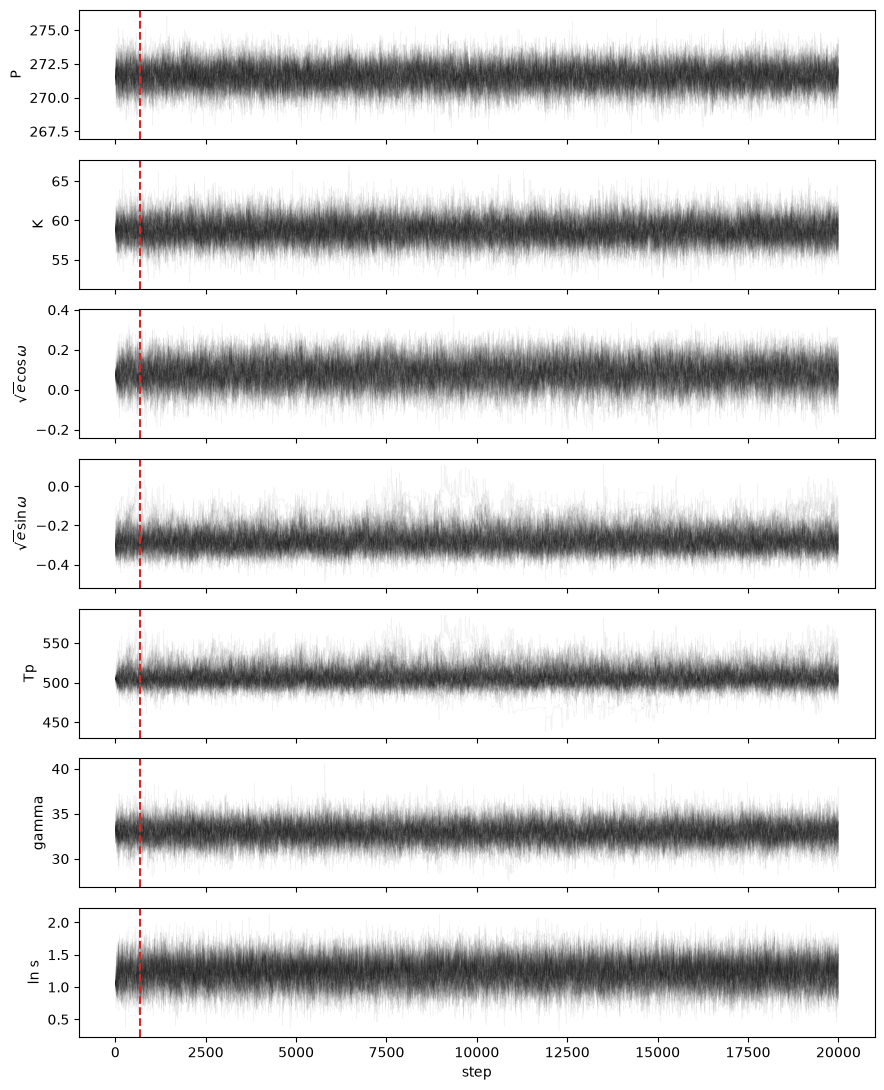

In [7]:
chain = sampler.get_chain()
labels = ['P', 'K', r'$\sqrt{e}\cos\omega$', r'$\sqrt{e}\sin\omega$', 'Tp', 'gamma', 'ln s']
fig, axes = plt.subplots(ndim, 1, figsize=(9, 11), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], color='k', alpha=0.05, lw=0.4)
    ax.axvline(burn, color='C3', ls='--')
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel('step')
plt.tight_layout()
plt.show()

I used a burn-in of $3\tau_{max}$ and thinned by $\tau_{max}/2$, the lab said a few tau and that is enough here since the traces are already flat after the red line. The slowest parameters are $\sqrt{e}\sin\omega$ and $T_p$ ($\tau$ ~230), because the eccentricty is small so those two are hard to pin down. My first run with 10000 steps was under 50$\tau$, so I made it 20000 steps (~90$\tau$).

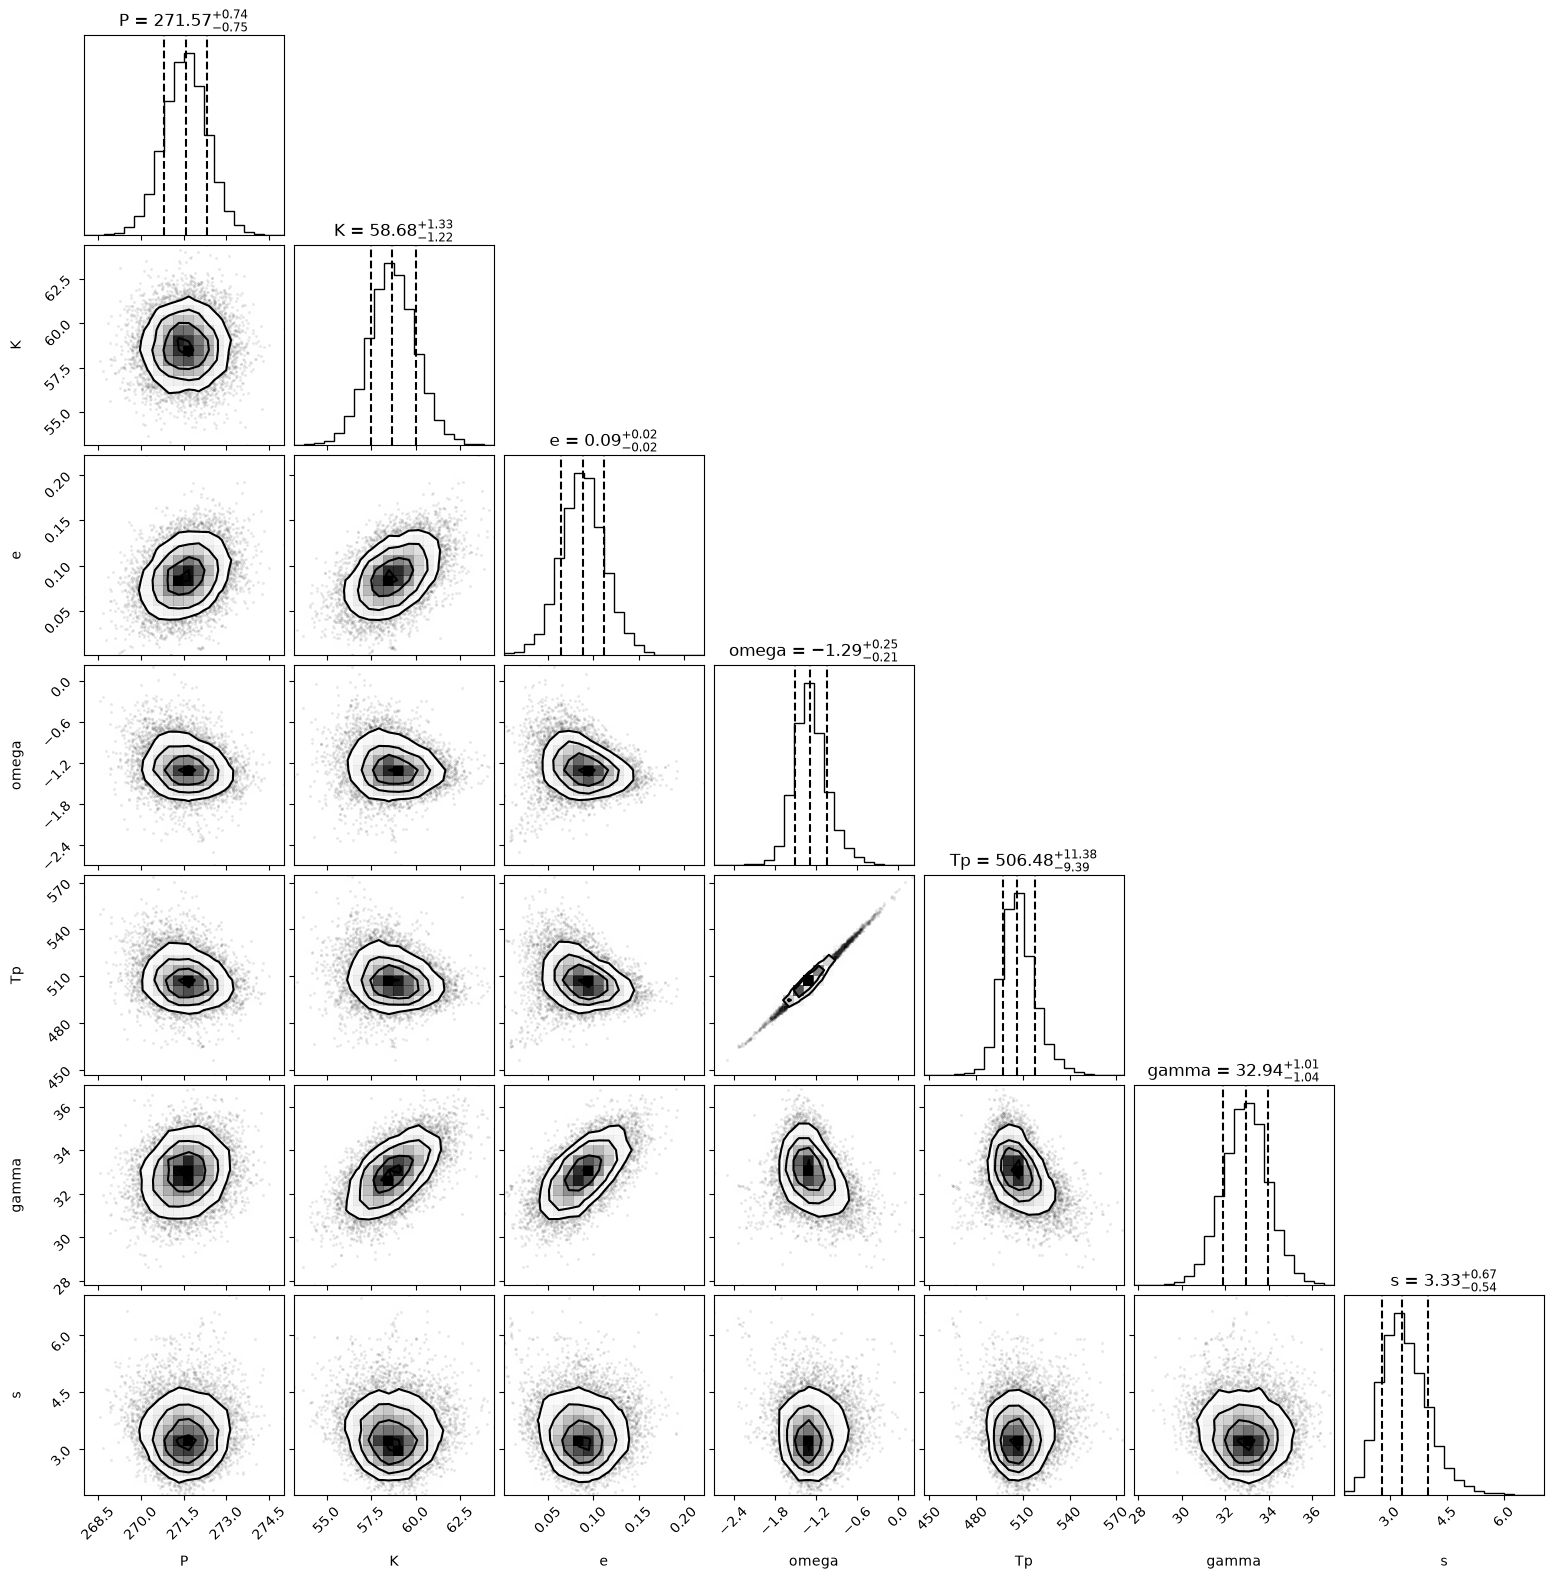

P      =   271.566 +0.742 -0.752
K      =    58.683 +1.334 -1.221
e      =     0.088 +0.024 -0.023
omega  =    -1.290 +0.252 -0.214
Tp     =   506.478 +11.376 -9.389
gamma  =    32.941 +1.007 -1.039
s      =     3.328 +0.674 -0.535
f(M)   =     5.619 +0.366 -0.335
P(f(M) < 3 Msun) = 0.0
f(M) from the medians instead: 5.62


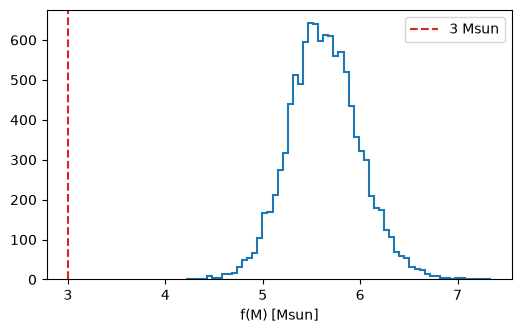

In [8]:
P_s, K_s, e_s, w_s, Tp_s, g_s, s_s = to_phys(flat)
samples = np.vstack([P_s, K_s, e_s, w_s, Tp_s, g_s, s_s]).T
fig = corner.corner(samples, labels=names, quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt='.2f')
plt.show()

fM_s = mass_function(P_s, K_s, e_s)
def summ(x):
    lo, mid, hi = np.percentile(x, [16, 50, 84])
    return mid, hi - mid, mid - lo
for n, x in zip(names + ['f(M)'], [P_s, K_s, e_s, w_s, Tp_s, g_s, s_s, fM_s]):
    m, up, dn = summ(x)
    print(f'{n:6s} = {m:9.3f} +{up:.3f} -{dn:.3f}')
print('P(f(M) < 3 Msun) =', np.mean(fM_s < 3.))
print('f(M) from the medians instead:', round(mass_function(np.median(P_s), np.median(K_s), np.median(e_s)), 3))

plt.figure(figsize=(6, 3.5))
plt.hist(fM_s, 60, histtype='step', lw=1.5)
plt.axvline(3., color='C3', ls='--', label='3 Msun')
plt.xlabel('f(M) [Msun]')
plt.legend()
plt.show()

**Corner plot:** $\omega$ and $T_p$ are very strongly correlated. The orbit is almost circular, so changing where periastron is (the angle) and when it happens (the time) does pretty much the same thing to the curve. $K$, $e$ and $\gamma$ are a bit correlated with each other too, I think because the $e\cos\omega$ term in the model also moves the curve up/down like $\gamma$, and we don't have data near the peak of the curve.

**Why f(M) per sample:** f(M) goes as $K^3$, so its not linear, and putting in the median P, K, e doesn't give you the median of f(M). Doing it per sample gives the actual distribution. For my data it ends up almost the same anyway (5.620 vs 5.619) because K is measured pretty precisely.

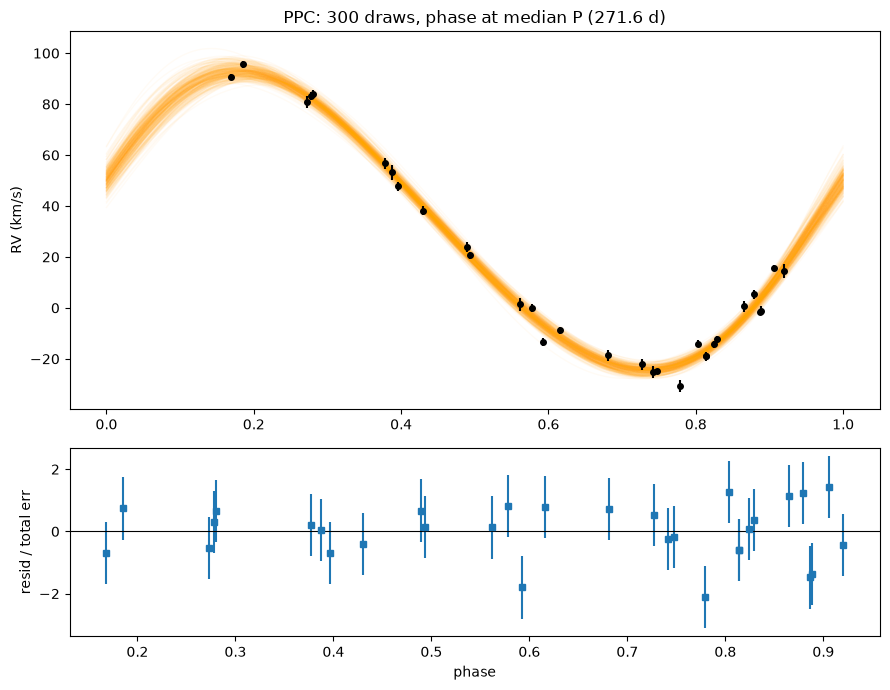

chi2 with total error = 24.5 for N = 31
std of normalized residuals = 0.89  max |resid| = 2.1
chi2 with sigma only = 139.1


In [9]:
# posterior predictive check
P_med = np.median(P_s)
Tp_med = np.median(Tp_s)
idx = np.random.default_rng(1).integers(0, flat.shape[0], 300)
t_fine = np.linspace(Tp_med, Tp_med + P_med, 400)
fig, ax = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw=dict(height_ratios=[2, 1]))
for j in idx:
    ax[0].plot((t_fine - Tp_med) / P_med, kepler_rv(t_fine, P_s[j], K_s[j], e_s[j], w_s[j], Tp_s[j], g_s[j]), color='orange', alpha=0.04, lw=1)
ph = ((t - Tp_med) / P_med) % 1.0
ax[0].errorbar(ph, rv, sig, fmt='o', ms=4, color='k')
ax[0].set_ylabel('RV (km/s)')
ax[0].set_title(f'PPC: 300 draws, phase at median P ({P_med:.1f} d)')

med_model = kepler_rv(t, P_med, np.median(K_s), np.median(e_s), np.median(w_s), Tp_med, np.median(g_s))
tot = np.sqrt(sig**2 + np.median(s_s)**2)
nres = (rv - med_model) / tot
ax[1].errorbar(ph, nres, np.ones_like(nres), fmt='s', ms=4)
ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_xlabel('phase')
ax[1].set_ylabel('resid / total err')
plt.tight_layout()
plt.show()
print('chi2 with total error =', round(np.sum(nres**2), 1), 'for N =', t.size)
print('std of normalized residuals =', round(np.std(nres), 2), ' max |resid| =', round(np.max(np.abs(nres)), 2))
print('chi2 with sigma only =', round(np.sum(((rv - med_model) / sig)**2), 1))

The posterior orbits go through the data. The normalized residuals using the total error look like noise, they're scattered around 0 with std about 0.9 and no pattern with phase. Using only the pipeline errors the chi2 is around 140 for 31 points, so the jitter is definitely needed.

**FINAL ANSWER:** $P = 271.57 \pm 0.75$ d, $K = 58.7 \pm 1.3$ km/s, $e = 0.088 \pm 0.024$, $\gamma = 32.9 \pm 1.0$ km/s, $s = 3.3 \pm 0.6$ km/s, $f(M) = 5.62 \pm 0.35$ $M_\odot$

**Black-hole candidate?** Yes, f(M) is a lower limit on the companion mass and it is well above 3 $M_\odot$ (none of the samples are below 3).

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


In [10]:
# Part 3: run the AI solution's analysis on my data, as written
P_peak = P_ls
P_prior_sigma = 0.5

def ai_log_prior(theta):
    P, K, e, omega, Tp, gamma = theta
    if not (0. < K < 200. and 0. <= e < 0.95 and 0. <= omega < 2 * np.pi and 0. <= Tp < P and -200. < gamma < 200.):
        return -np.inf
    return -0.5 * ((P - P_peak) / P_prior_sigma)**2

def ai_log_likelihood(theta):
    model = kepler_rv(t, *theta)
    return -0.5 * np.sum(((rv - model) / sig)**2)

def ai_log_posterior(theta):
    lp = ai_log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + ai_log_likelihood(theta)

x0 = [P_peak, 0.5 * (rv.max() - rv.min()), 0.3, 1.0, t.min() + 0.3 * P_peak, np.median(rv)]
res = minimize(lambda th: -ai_log_posterior(th), x0, method='Nelder-Mead', options=dict(maxiter=6000))
theta_map_ai = res.x
print('AI MAP:', np.round(theta_map_ai, 3))

np.random.seed(42)
rng_ai = np.random.default_rng(42)
p0_ai = theta_map_ai + 1e-3 * rng_ai.normal(size=(24, 6))
p0_ai[:, 4] = np.abs(p0_ai[:, 4])
ai_sampler = emcee.EnsembleSampler(24, 6, ai_log_posterior)
ai_sampler.run_mcmc(p0_ai, 1500, progress=False)
ai_flat = ai_sampler.get_chain(discard=100, flat=True)
ai_med = np.median(ai_flat, axis=0)
ai_sd = np.std(ai_flat, axis=0)
for n, m, s in zip(['P', 'K', 'e', 'omega', 'Tp', 'gamma'], ai_med, ai_sd):
    print(f'AI  {n:6s} = {m:9.3f} +/- {s:.3f}')
# its f(M) (medians + first order propagation) and reduced chi2, same as the AI notebook
fM_ai = mass_function(*ai_med[:3])
fM_ai_err = np.sqrt((fM_ai / ai_med[0] * ai_sd[0])**2 + (3 * fM_ai / ai_med[1] * ai_sd[1])**2
                    + (3 * ai_med[2] * fM_ai / (1 - ai_med[2]**2) * ai_sd[2])**2)
print(f'AI  f(M) = {fM_ai:.2f} +/- {fM_ai_err:.2f}')
print('AI  reduced chi2 =', round(np.sum(((rv - kepler_rv(t, *ai_med)) / sig)**2) / (t.size - 6), 2))

AI MAP: [262.882  56.912   0.521   0.     47.693   1.081]


/opt/anaconda3/envs/astr457/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


AI  P      =   271.022 +/- 3.636
AI  K      =    58.678 +/- 3.146
AI  e      =     0.089 +/- 0.148
AI  omega  =     4.971 +/- 1.684
AI  Tp     =   234.483 +/- 62.770
AI  gamma  =    32.780 +/- 9.721
AI  f(M) = 5.61 +/- 0.93
AI  reduced chi2 = 5.65


              with jitter          no jitter
P        271.566 +/- 0.767     271.428 +/- 0.331   width ratio 2.32
K         58.683 +/- 1.321      58.686 +/- 0.472   width ratio 2.80
e          0.088 +/- 0.025       0.089 +/- 0.010   width ratio 2.52
gamma     32.941 +/- 1.045      32.987 +/- 0.387   width ratio 2.70
f(M)       5.619 +/- 0.364       5.616 +/- 0.131   width ratio 2.78
reduced chi2 of no-jitter fit: 5.54


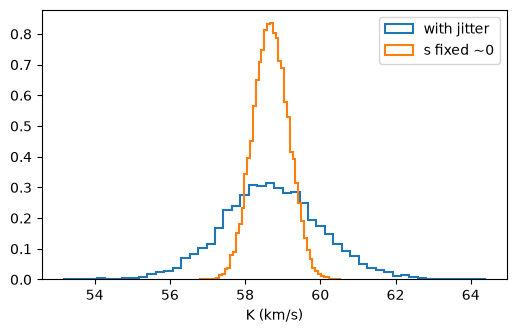

In [11]:
# Error 1: no jitter. Same correct setup as Part 2 but s fixed at ~0
def log_post_nojit(th6):
    return lnpost(np.append(th6, -4.9), rv, Tp_mid)
np.random.seed(1)
p0_nj = theta_ml[:6] + scale[:6] * np.random.default_rng(1).normal(size=(64, 6))
s_nj = emcee.EnsembleSampler(64, 6, log_post_nojit)
s_nj.run_mcmc(p0_nj, 8000, progress=False)
tau_nj = s_nj.get_autocorr_time(tol=0)
fl_nj = s_nj.get_chain(discard=int(3*tau_nj.max()), thin=int(tau_nj.max()/2), flat=True)
P_n, K_n, e_n, w_n, Tp_n, g_n, _ = to_phys(np.column_stack([fl_nj, np.full(len(fl_nj), -4.9)]))
fM_n = mass_function(P_n, K_n, e_n)
print('              with jitter          no jitter')
for n, a, b in zip(['P', 'K', 'e', 'gamma', 'f(M)'], [P_s, K_s, e_s, g_s, fM_s], [P_n, K_n, e_n, g_n, fM_n]):
    print(f'{n:6s}  {np.median(a):8.3f} +/- {np.std(a):.3f}    {np.median(b):8.3f} +/- {np.std(b):.3f}   width ratio {np.std(a)/np.std(b):.2f}')
mod_nj = kepler_rv(t, np.median(P_n), np.median(K_n), np.median(e_n), np.median(w_n), np.median(Tp_n), np.median(g_n))
print('reduced chi2 of no-jitter fit:', round(np.sum(((rv - mod_nj)/sig)**2) / (t.size - 6), 2))

plt.figure(figsize=(6, 3.5))
plt.hist(K_s, 50, density=True, histtype='step', lw=1.5, label='with jitter')
plt.hist(K_n, 50, density=True, histtype='step', lw=1.5, label='s fixed ~0')
plt.xlabel('K (km/s)')
plt.legend()
plt.show()

periodogram peak P_ls = 270.31
P, broad prior:         271.57 +/- 0.77
P, N(P_ls, 0.5) prior:  270.69 +/- 0.43
shift = 1.1 sigma of the real posterior
AI run (prior + no jitter): P = 271.02 +/- 3.64


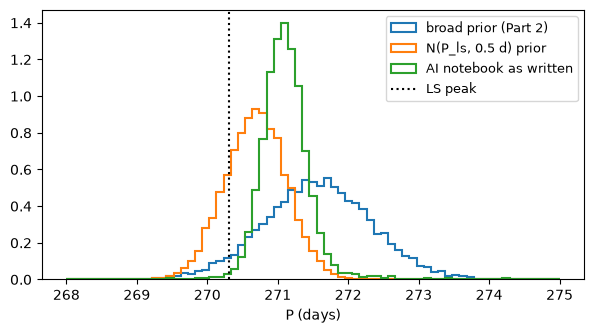

In [12]:
# Error 2: the periodogram peak used as a N(P_ls, 0.5 d) prior. Correct likelihood (with jitter), only the P prior changed
def log_post_Pprior(theta):
    lp = lnpost(theta, rv, Tp_mid)
    return lp - 0.5 * ((theta[0] - P_ls) / 0.5)**2 + np.log(theta[0])
np.random.seed(2)
s_pp = emcee.EnsembleSampler(64, 7, log_post_Pprior)
s_pp.run_mcmc(p0, 8000, progress=False)
tau_pp = s_pp.get_autocorr_time(tol=0)
fl_pp = s_pp.get_chain(discard=int(3*tau_pp.max()), thin=int(tau_pp.max()/2), flat=True)
P_p = fl_pp[:, 0]
print('periodogram peak P_ls =', round(P_ls, 2))
print('P, broad prior:        ', round(np.median(P_s), 2), '+/-', round(np.std(P_s), 2))
print('P, N(P_ls, 0.5) prior: ', round(np.median(P_p), 2), '+/-', round(np.std(P_p), 2))
print('shift =', round((np.median(P_s) - np.median(P_p)) / np.std(P_s), 1), 'sigma of the real posterior')
print('AI run (prior + no jitter): P =', round(ai_med[0], 2), '+/-', round(ai_sd[0], 2))

plt.figure(figsize=(7, 3.5))
bins = np.linspace(268, 275, 70)
plt.hist(P_s, bins, density=True, histtype='step', lw=1.5, label='broad prior (Part 2)')
plt.hist(P_p, bins, density=True, histtype='step', lw=1.5, label='N(P_ls, 0.5 d) prior')
plt.hist(ai_flat[:, 0], bins, density=True, histtype='step', lw=1.5, label='AI notebook as written')
plt.axvline(P_ls, color='k', ls=':', label='LS peak')
plt.xlabel('P (days)')
plt.legend(fontsize=9)
plt.show()

In [13]:
# Error 3: hard walls 0 <= omega < 2pi and 0 <= Tp < P. Same AI posterior and start, walls removed
def ai_log_posterior_nowall(theta):
    P, K, e, omega, Tp, gamma = theta
    if not (0. < K < 200. and 0. <= e < 0.95 and -200. < gamma < 200.):
        return -np.inf
    return -0.5 * ((P - P_peak) / P_prior_sigma)**2 + ai_log_likelihood(theta)

res_nw = minimize(lambda th: -ai_log_posterior_nowall(th), x0, method='Nelder-Mead', options=dict(maxiter=6000))
print('with walls:    MAP =', np.round(res.x, 3), ' log post =', round(-res.fun, 1))
print('without walls: MAP =', np.round(res_nw.x, 3), ' log post =', round(-res_nw.fun, 1))
print('true omega (Part 2) =', round(np.median(w_s), 2), 'rad =', round(np.median(w_s) % (2*np.pi), 2), 'rad')

with walls:    MAP = [262.882  56.912   0.521   0.     47.693   1.081]  log post = -3569.8
without walls: MAP = [ 2.71088e+02  5.87370e+01  8.70000e-02 -1.28800e+00 -3.55810e+01
  3.29990e+01]  log post = -71.0


true omega (Part 2) = -1.29 rad = 4.99 rad


**REFEREE REPORT:**

When I run the AI notebook on my data, its MAP starting point is stuck at omega = 0 with e = 0.52, and the chain gives $P = 271.0 \pm 3.6$ d, $e = 0.09 \pm 0.15$, $\omega = 5.0 \pm 1.7$ rad and $T_p$ with a $\pm 63$ d spread, $f(M) = 5.6 \pm 0.9$. The medians end up near my Part 2 values, but the error bars are huge because some of the walkers are still sitting near the wall at omega = 0 while the rest moved to omega ~5 rad, so the chain hasn't converged even though the notebook says it has.

**1. No jitter term.** The likelihood only uses the pipeline errors, even though the fit has a reduced chi2 of about 5.6 (the notebook prints this and calls it "natural variance"). I ran my own sampler with s fixed to almost 0: the best fit values barely change but all the error bars get about 2.5x smaller, for example K goes from 1.32 to 0.47 km/s (histogram above). So without jitter the errors are too small. Fix: add $s^2$ to $\sigma_i^2$, sample $\ln s$, and keep the log term in the likelihood like in Part 2. For me s is about 3.3 km/s, which is bigger than the quoted errors.

**2. Tight prior on P from the periodogram.** The AI puts a Gaussian prior with width 0.5 d at the LS peak. This uses the data twice, and the LS peak is from a sine fit not a Keplerian one. My LS peak is at 270.31 d while the posterior is at 271.6 d. With the AI prior (but jitter included) P moves to 270.7 d and the error goes from 0.77 to 0.43 d, so it is shifted by about 1.1 sigma and looks more precise than it is. And if the highest peak were an alias, this prior would keep it there. Fix: use a broad prior on P and only use the periodogram to choose starting points.

**3. Hard walls on omega and Tp.** The AI requires $0 \le \omega < 2\pi$ and $0 \le T_p < P$. For my star this is the biggest problem: the true omega is about -1.3 rad (= 5.0 rad) but the AI starts at 1.0, so the optimizer moves down, hits the wall at omega = 0 and stops there with e = 0.52 (log posterior about -3570). If I take out only the walls, the same optimizer from the same start finds omega = -1.29 and e = 0.09 (log posterior -71). The walkers then start in a tiny ball right at the wall, and after 1500 steps some of them are still stuck there, which is where the huge omega/Tp spread comes from. The notebook calls this converged from the trace plots and uses tol=0 so emcee doesn't warn that 1500 steps is too short. Fix: sample $\sqrt{e}\cos\omega$ and $\sqrt{e}\sin\omega$ instead, use a Tp window around the best fit, and start from several ML fits.

## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


In [14]:
# Part 4: injection-recovery test on a fake star at my epochs and errors
# fake star: P, K, e, omega, Tp, gamma, s
true_vals = np.array([380., 33., 0.35, 2.2, 100., 12., 2.])
rng_f = np.random.default_rng(2026)
rv_fake = kepler_rv(t, *true_vals[:6]) + rng_f.normal(0, np.sqrt(sig**2 + true_vals[6]**2))

pw_f = LombScargle(t, rv_fake, sig).power(freq)
pkf, _ = find_peaks(pw_f)
topf = pkf[np.argsort(pw_f[pkf])[::-1][:3]]
best_f = None
for P0 in periods[topf]:
    for w0 in np.linspace(0, 2*np.pi, 6, endpoint=False):
        for f0 in [0., 0.33, 0.67]:
            x0 = [P0, 0.5*np.ptp(rv_fake), 0.4*np.cos(w0), 0.4*np.sin(w0), t.min() + f0*P0, np.median(rv_fake), 0.5]
            r = minimize(nll, x0, args=(rv_fake,), method='Nelder-Mead', options=dict(maxiter=8000, maxfev=8000, xatol=1e-6, fatol=1e-6))
            if best_f is None or r.fun < best_f.fun:
                best_f = r
np.random.seed(7)
pf0 = best_f.x + scale * np.random.default_rng(7).normal(size=(64, 7))
sf = emcee.EnsembleSampler(64, 7, lnpost, args=(rv_fake, best_f.x[4]))
sf.run_mcmc(pf0, 15000, progress=False)
tau_f = sf.get_autocorr_time(tol=0)
fl_f = sf.get_chain(discard=int(3*tau_f.max()), thin=int(tau_f.max()/2), flat=True)

got = to_phys(fl_f)
# Tp is only defined mod P: use the phase difference from the true Tp instead
dph = np.angle(np.exp(2j * np.pi * (got[4] - true_vals[4]) / got[0])) / (2 * np.pi)
got[4] = true_vals[4] + dph * got[0]
print('tau max:', round(tau_f.max()), ' chain/tau =', round(15000/tau_f.max()))
n_in = 0
for n, x, tv in zip(names, got, true_vals):
    lo, mid, hi = np.percentile(x, [16, 50, 84])
    ok = lo < tv < hi
    n_in += ok
    print(f'{n:6s} truth {tv:8.3f}  got {mid:8.3f} +{hi-mid:.3f} -{mid-lo:.3f}', 'ok' if ok else 'outside')
fM_true = mass_function(*true_vals[:3])
lo, mid, hi = np.percentile(mass_function(got[0], got[1], got[2]), [16, 50, 84])
print(f'f(M)   truth {fM_true:8.3f}  got {mid:8.3f} +{hi-mid:.3f} -{mid-lo:.3f}')
print(n_in, 'of 7 inside 68% interval')

tau max: 226  chain/tau = 66
P      truth  380.000  got  381.070 +1.072 -1.141 ok
K      truth   33.000  got   33.294 +0.645 -0.606 ok
e      truth    0.350  got    0.350 +0.016 -0.017 ok
omega  truth    2.200  got    2.175 +0.081 -0.071 ok
Tp     truth  100.000  got   97.212 +4.402 -3.709 ok
gamma  truth   12.000  got   11.936 +0.556 -0.526 ok
s      truth    2.000  got    1.503 +0.520 -0.512 ok
f(M)   truth    1.163  got    1.196 +0.077 -0.067
7 of 7 inside 68% interval


**AI-USE APPENDIX:**

I used Claude Code for this lab, mostly to write the code (including the Part 3 demos) and to help draft and organize the write-up. I read the Day 12-14 lectures and the lab first, and I checked all the numbers against the outputs. Its first chain was too short for $T_p$ so I made it longer, and the first draft of the report called the omega walls a minor issue before it had actually tested it, but for my star it's the main problem.

**REFLECTION:**

I mostly used AI to write the code quickly. If I hadn't checked, the report would have said the walls don't matter for my data, which is the opposite of what happens. Also in the injection test Tp has to be compared mod P, otherwise it looks like a big miss.

**VERIFICATION PLAN:**

- ML fits starting from each candidate period: 271.6 d has a much higher lnL than the best fit at any other period (29.1 d, lower by 62). If two periods were close I would need to sample both.
- Autocorrelation time with the default tolerance, chain is ~90 tau long, traces flat. Failure would be emcee raising the error or the traces still drifting.
- Posterior predictive check: residuals look like noise. Failure would be some leftover pattern.
- Injection test: a fake orbit with P = 380 d, K = 33, e = 0.35, s = 2 at my epochs and errors, run through the same code. All 7 parameters came back within their 68% intervals, which is a bit better than the ~5 of 7 you'd expect, but it's only one fake dataset. Failure would be something off by several sigma or ending up at an alias period.